# Homework 4

## Consegna

 ### 1. Compressione di immagini

Caricare e visualizzare un’immagine (diversa
dal cameraman) in scala di grigio con matrice associata A di dimensione $mxn$. Fissati alcuni valori di $p$:


Inclusione librerie

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
from skimage.color import rgb2gray

Inserimento dell'immagine

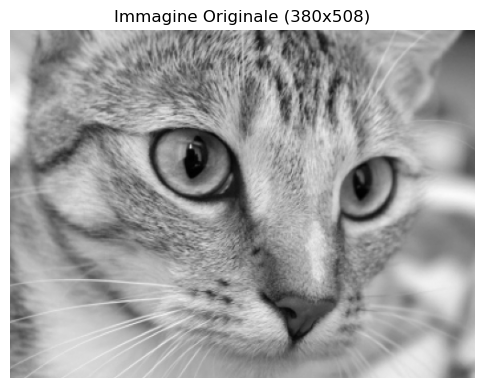

In [3]:
filename = 'gatto.bmp'
try:
    image_source = io.imread(filename)
except FileNotFoundError:
    print(f"ERRORE: Non trovo il file '{filename}'. Controlla il nome o la cartella.")
    raise

if image_source.ndim == 3:
    A_img = rgb2gray(image_source)
else:
    A_img = image_source

if A_img.max() > 1.0:
    A_img = A_img / 255.0

m, n = A_img.shape

plt.figure(figsize=(6, 6))
plt.imshow(A_img, cmap='gray')
plt.title(f"Immagine Originale ({m}x{n})")
plt.axis('off')
plt.show()

Calcolare la matrice

$$
A_p = \sum_{i=1}^p u_i*v_i^T*σ_i
$$

dove $p ≤ rango(A)$ e la visualizzo

In [4]:
def Ap(U, s, Vt, p):
    S_p = np.diag(s[:p])
    A_p = U[:, :p] @ S_p @ Vt[:p, :]
    return A_p

Calcolare l'errore relativo:

$$ER=\frac{||A-A_p||_2}{||A||_2}$$

In [5]:
def errore_relativo(A, A_p, errors): 
    norm_A = np.linalg.norm(A, 'fro')
    norm_diff = np.linalg.norm(A - A_p, 'fro')
    rel_err = norm_diff / norm_A
    errors.append(rel_err)

Calcolare il fattore di compressione

$$c_p=\frac{1}{p}min(m,n)-1$$

In [6]:
def cp(A, p, compression_factors):
    c_p = (1/p) * min(A.shape) - 1
    compression_factors.append(c_p)

Calcolare e plottare l’ errore relativo e il fattore di compressione al variare
di p.

In [ ]:
def plot_results(p_values, errors, compression_factors):
    fig, ax1 = plt.subplots(figsize=(10, 5))

    color = 'tab:red'
    ax1.set_xlabel('Valore di p (rango)')
    ax1.set_ylabel('Errore Relativo', color=color)
    ax1.plot(p_values, errors, marker='o', color=color, label='Errore Relativo')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True)

    ax2 = ax1.twinx() 
    color = 'tab:blue'
    ax2.set_ylabel('Fattore di Compressione (cp)', color=color)
    ax2.plot(p_values, compression_factors, marker='s', linestyle='--', color=color, label='Fattore Compressione')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title("Andamento Errore Relativo e Fattore di Compressione")
    plt.show()

In [8]:
p_values = [5, 20, 50, 100, 150]

def svd_compression(A, p_values):
    U, s, Vt = np.linalg.svd(A, full_matrices=False)

    errors = []
    compression_factors = []

    plt.figure(figsize=(15, 8))

    for i, p in enumerate(p_values):
        if p > min(A.shape):
            continue

        A_p = Ap(U, s, Vt, p)

        errore_relativo(A, A_p, errors)

        cp(A, p, compression_factors)

        plt.subplot(2, 3, i+1)
        plt.imshow(A_p, cmap='gray')
        plt.title(f"p={p}\nErr: {errors[-1]:.4f}, Cp: {compression_factors[-1]:.2f}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()
    plot_results(p_values, errors, compression_factors)

Test delle funzioni

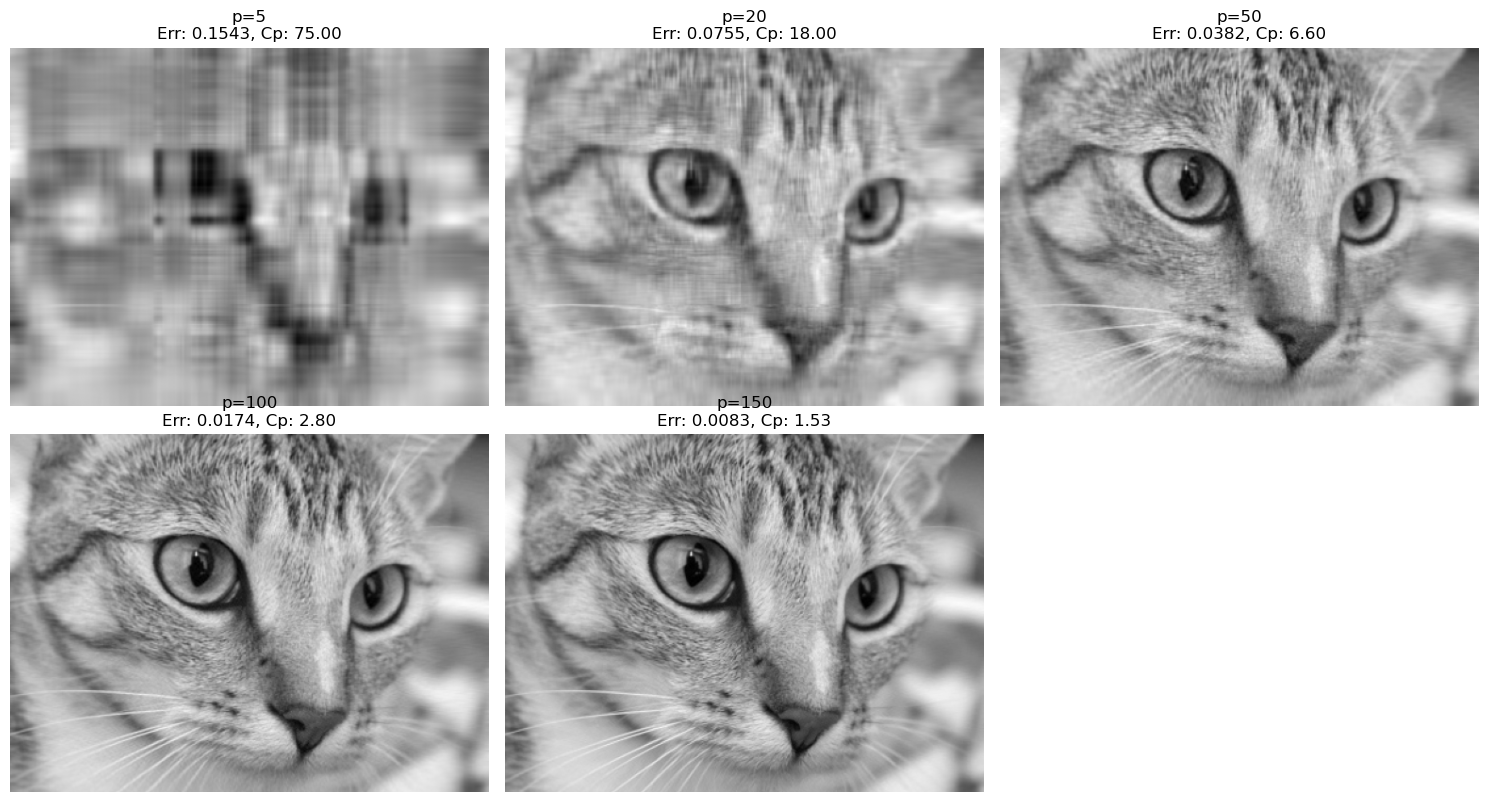

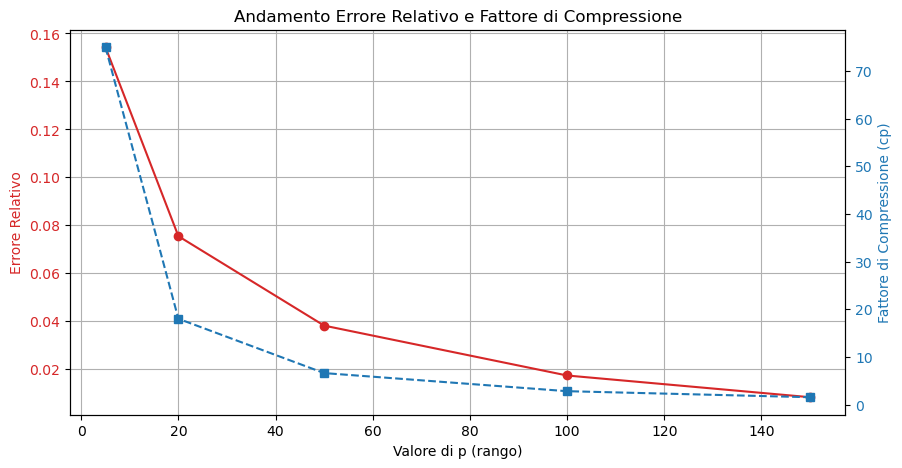

In [9]:
svd_compression(A_img, p_values)



 ### 2. Image deblur




Inclusione della cartella Problemi inversi

In [10]:
from ProblemiInversi import operators, solvers, utilities

Creare un problema test

In [11]:
def stamp_kernel(sigma):
    k_size = 15
    kernel = utilities.gaussian2d_kernel(k_size, sigma)
    plt.imshow(kernel, cmap='hot')
    plt.axis('off')
    plt.show()

In [12]:
def prob_test(nl, sigma, x_true):
    k_size = 15
    kernel = utilities.gaussian2d_kernel(k_size, sigma)
    A = operators.ConvolutionOperator(kernel)
    b_clean = A(x_true)

    noise = utilities.gaussian_noise(b_clean, nl)
    b_noisy = b_clean + noise
    noise_realization = b_noisy - b_clean
    delta = np.linalg.norm(noise_realization)

    print(f"\n--- Livello di Rumore: {nl*100}% (Delta: {delta:.4f}) ---")
    return b_noisy, A, delta

Calcolare la soluzione naive risolvendo il problema di minimi quadrati
con CGLS

In [13]:
def CGLS(b_noisy, x_true, A, max_iter_cgls):
    print("Calcolo soluzione Naive (CGLS)...")
    solver_naive = solvers.CGLS(A) 
    x0 = np.zeros_like(b_noisy)
    x_naive = solver_naive.solve(b_noisy, x0, kmax=max_iter_cgls)
        
    err_naive = utilities.rel_err(x_naive, x_true)
    print(f"-> Naive Error: {err_naive:.4f}")
    return x_naive, err_naive

Calcolare la soluzione regolarizzata con Tikhonov. Calcolare il valore
di λ sia con il principio di Massima Discrepanza che come valore
che minimizza l’errore assoluto fra l’immagine ground truth e la ricostruzione
(su una griglia di valori di λ), visualizzando il grafico
relativo.

In [14]:
def Tik(b_noisy, x_true, A, max_iter_cgls, lambdas_tik, delta, x0):
    print("Calcolo soluzione Tikhonov...")

    best_err_tik = float('inf')
    best_lam_tik = 0
    best_x_tik = None

    tik_errors = []
    tik_residuals = []
    x_tik_disc = None
    best_disc_diff = float('inf')
    lam_disc_tik = 0

    L = operators.Identity()

    for lam in lambdas_tik:
        solver_tik = solvers.CGLS(A, L=L, lmbda=lam)
        x_tik = solver_tik.solve(b_noisy, x0, kmax=max_iter_cgls)

        err = utilities.rel_err(x_tik, x_true)
        tik_errors.append(err)

        if err < best_err_tik:
            best_err_tik = err
            best_lam_tik = lam
            best_x_tik = x_tik

        res_norm = np.linalg.norm(A(x_tik) - b_noisy)
        tik_residuals.append(res_norm)

        diff = abs(res_norm - delta)
        if diff < best_disc_diff:
            best_disc_diff = diff
            x_tik_disc = x_tik
            lam_disc_tik = lam

    print(f"-> Tikhonov Best (vs GT): Lambda={best_lam_tik:.5f}, Err={best_err_tik:.4f}")
    print(f"-> Tikhonov Discrepancy: Lambda={lam_disc_tik:.5f}, Err={utilities.rel_err(x_tik_disc, x_true):.4f}")

    return best_x_tik, tik_errors, x_tik_disc, best_err_tik

Calcolare la soluzione regolarizzata con Total Variation. Calcolare
il valore di λ come valore che minimizza l’errore assoluto (in norma
2) fra l’immagine ground truth e la ricostruzione (su una griglia di
valori di λ) visualizzando il grafico relativo.

In [15]:
def TV(b_noisy, x_true, A, lambdas_tv, x0):
    print("Calcolo soluzione Total Variation (Gradient Descent)...")

    beta = 1e-3
    gd_tv_solver = solvers.GDTotalVariation(A, beta=beta)

    kmax = 30
    tolf = 1e-8
    tolx = 1e-8

    best_err_tv = float('inf')
    best_lam_tv = 0
    best_x_tv = None
    tv_errors = []

    for lam in lambdas_tv:
        x_tv, _, _ = gd_tv_solver.solve(b_noisy, lam, x0, kmax, tolf, tolx)

        err = utilities.rel_err(x_tv, x_true)
        tv_errors.append(err)

        if err < best_err_tv:
            best_err_tv = err
            best_lam_tv = lam
            best_x_tv = x_tv

    print(f"-> TV Best (vs GT): Lambda={best_lam_tv:.5f}, Err={best_err_tv:.4f}")

    return best_x_tv, tv_errors, best_err_tv

Funzione per la visualizzazione

In [16]:
def plot_deblur_results(b_noisy, x_naive, err_naive, 
                 best_x_tik, best_err_tik, x_tik_disc, 
                 best_x_tv, best_err_tv, 
                 lambdas_tik, tik_errors, lambdas_tv, tv_errors, nl, sigma, x_true):

    plt.figure(figsize=(15, 5))

    titles = ["Dati Rumorosi", "Naive", "Tikhonov (Best)", "Tikhonov (Disc)", "TV (Best)"]
    images = [b_noisy, x_naive, best_x_tik, x_tik_disc, best_x_tv]

    if x_tik_disc is not None:
        err_disc = utilities.rel_err(x_tik_disc, x_true)
    else:
        err_disc = 0
    errors = [None, err_naive, best_err_tik, err_disc, best_err_tv]

    for i in range(5):
        plt.subplot(1, 5, i+1)
        plt.imshow(images[i], cmap='gray')
        t = titles[i]
        if errors[i] is not None:
            t += f"\nErr: {errors[i]:.3f}"
        plt.title(t)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.semilogx(lambdas_tik, tik_errors, 'b-o', label='Tikhonov')
    plt.semilogx(lambdas_tv, tv_errors, 'r-s', label='TV')
    plt.axhline(y=err_naive, color='k', linestyle='--', label='Naive Base')
    plt.xlabel('Lambda')
    plt.ylabel('Relative Error')
    plt.title(f'Errore vs Lambda (Sigma={sigma}, Noise={nl})')
    plt.legend()
    plt.grid(True)
    plt.show()

Test

In [17]:
def test(x_true, max_iter_cgls, lambdas_tik, lambdas_tv, sigmas, noise_levels):

    for sigma in sigmas:
        print(f"\n{'='*80}")
        print(f"ANALISI CON PSF SIGMA = {sigma}")
        print(f"{'='*80}")
        stamp_kernel(sigma)

        for nl in noise_levels:
            b_noisy, A, delta = prob_test(nl, sigma, x_true)
            x0_start = b_noisy.copy()

            x_naive, err_naive = CGLS(b_noisy, x_true, A, max_iter_cgls)

            best_x_tik, tik_errors, x_tik_disc, best_err_tik = Tik(
                b_noisy, x_true, A, max_iter_cgls, lambdas_tik, delta, x0_start
            )

            best_x_tv, tv_errors, best_err_tv = TV(
                b_noisy, x_true, A, lambdas_tv, x0_start
            )

            plot_deblur_results(b_noisy, x_naive, err_naive, 
                         best_x_tik, best_err_tik, x_tik_disc, 
                         best_x_tv, best_err_tv, 
                         lambdas_tik, tik_errors, lambdas_tv, tv_errors, nl, sigma, x_true)


ANALISI CON PSF SIGMA = 1


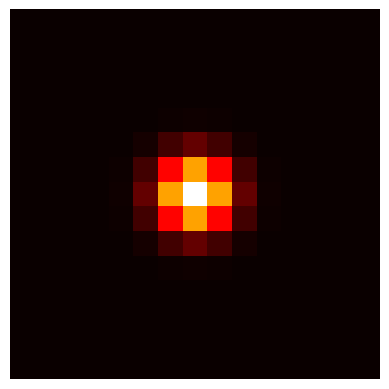


--- Livello di Rumore: 1.0% (Delta: 2.7010) ---
Calcolo soluzione Naive (CGLS)...
-> Naive Error: 0.3536
Calcolo soluzione Tikhonov...
-> Tikhonov Best (vs GT): Lambda=0.01668, Err=0.0330
-> Tikhonov Discrepancy: Lambda=0.00599, Err=0.0402
Calcolo soluzione Total Variation (Gradient Descent)...
-> TV Best (vs GT): Lambda=0.00077, Err=0.0265


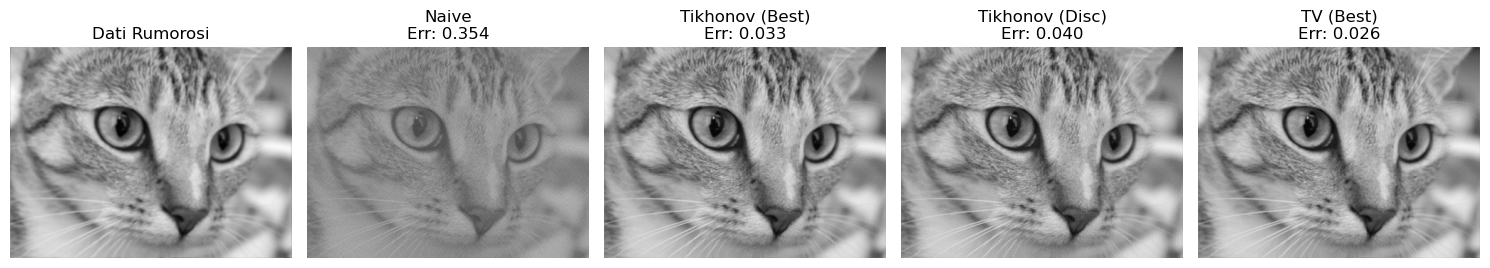

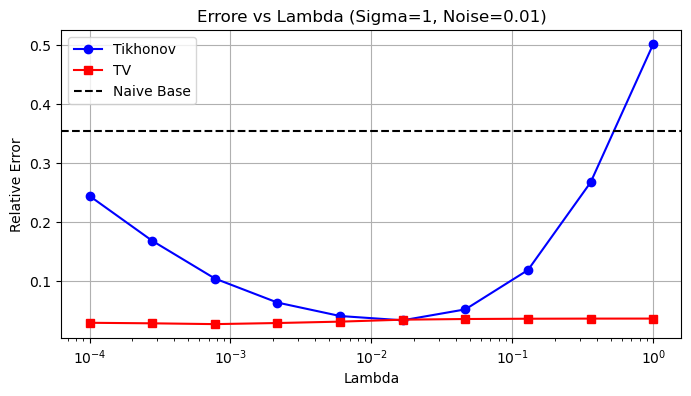


--- Livello di Rumore: 5.0% (Delta: 13.5049) ---
Calcolo soluzione Naive (CGLS)...
-> Naive Error: 1.8008
Calcolo soluzione Tikhonov...
-> Tikhonov Best (vs GT): Lambda=0.04642, Err=0.0810
-> Tikhonov Discrepancy: Lambda=0.01668, Err=0.1114
Calcolo soluzione Total Variation (Gradient Descent)...
-> TV Best (vs GT): Lambda=0.35938, Err=0.0562


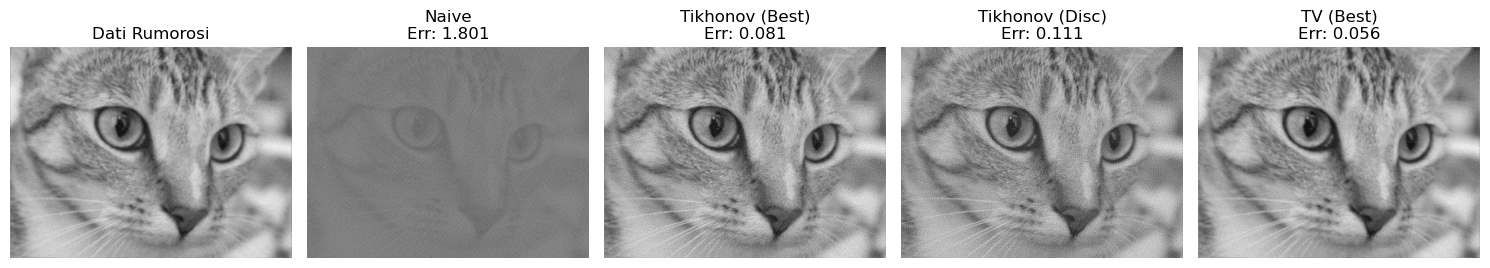

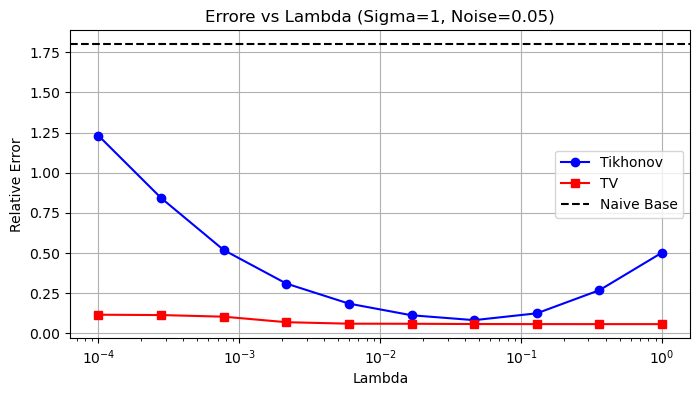


--- Livello di Rumore: 10.0% (Delta: 27.0099) ---
Calcolo soluzione Naive (CGLS)...
-> Naive Error: 3.5982
Calcolo soluzione Tikhonov...
-> Tikhonov Best (vs GT): Lambda=0.04642, Err=0.1373
-> Tikhonov Discrepancy: Lambda=0.04642, Err=0.1373
Calcolo soluzione Total Variation (Gradient Descent)...
-> TV Best (vs GT): Lambda=1.00000, Err=0.0959


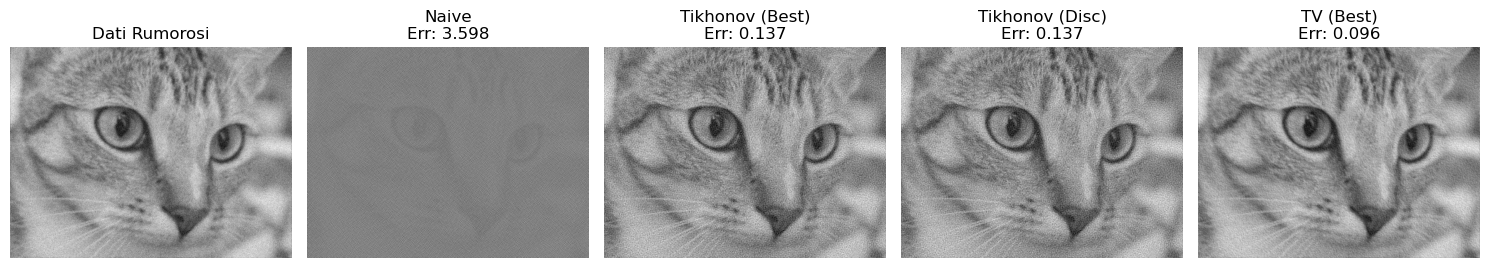

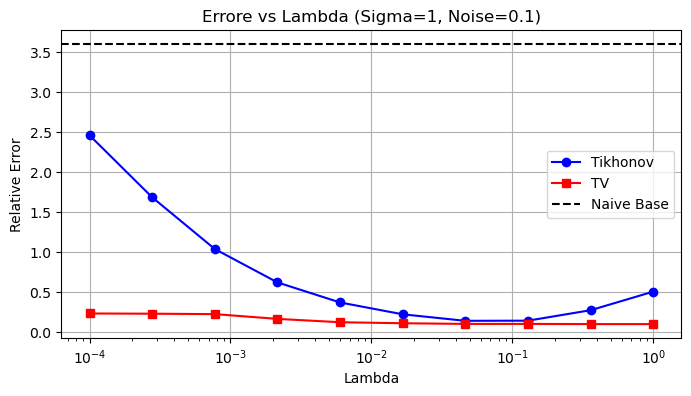


ANALISI CON PSF SIGMA = 3


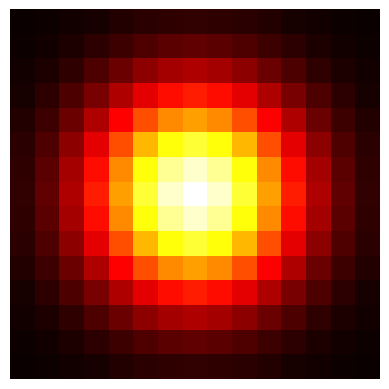


--- Livello di Rumore: 1.0% (Delta: 2.6881) ---
Calcolo soluzione Naive (CGLS)...
-> Naive Error: 0.2805
Calcolo soluzione Tikhonov...
-> Tikhonov Best (vs GT): Lambda=0.00215, Err=0.0549
-> Tikhonov Discrepancy: Lambda=0.00215, Err=0.0549
Calcolo soluzione Total Variation (Gradient Descent)...
-> TV Best (vs GT): Lambda=0.00010, Err=0.0578


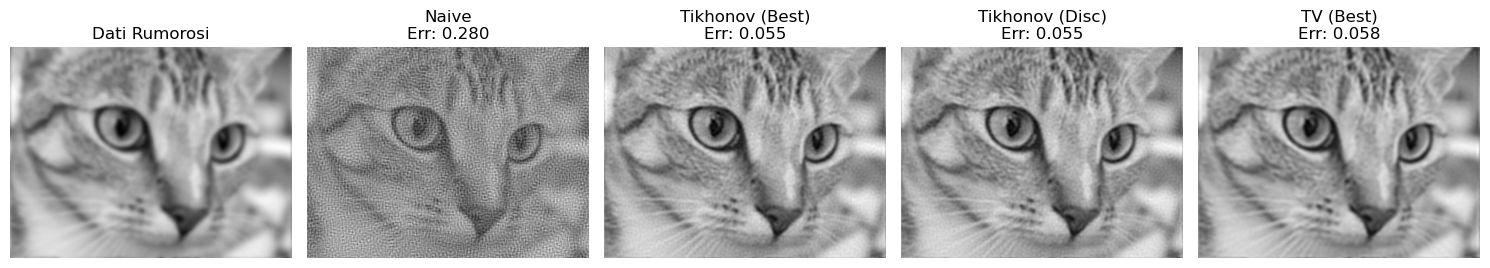

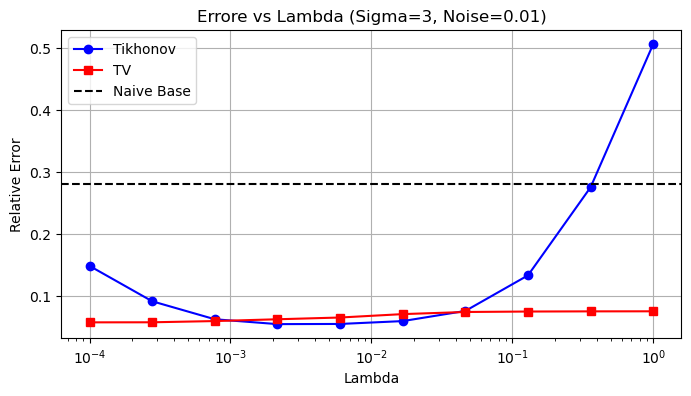


--- Livello di Rumore: 5.0% (Delta: 13.4403) ---
Calcolo soluzione Naive (CGLS)...
-> Naive Error: 1.5586
Calcolo soluzione Tikhonov...
-> Tikhonov Best (vs GT): Lambda=0.01668, Err=0.0691
-> Tikhonov Discrepancy: Lambda=0.00599, Err=0.0814
Calcolo soluzione Total Variation (Gradient Descent)...
-> TV Best (vs GT): Lambda=0.00215, Err=0.0770


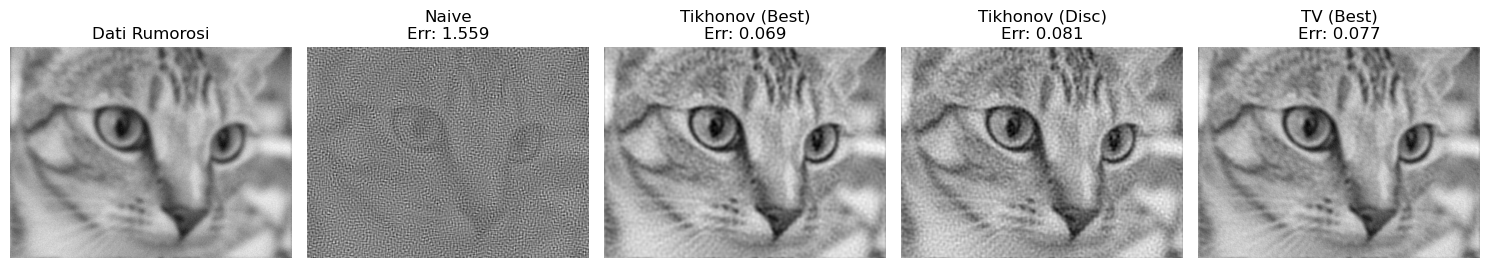

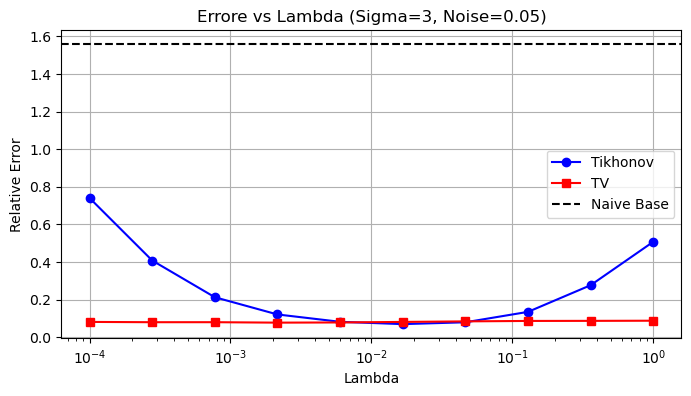


--- Livello di Rumore: 10.0% (Delta: 26.8805) ---
Calcolo soluzione Naive (CGLS)...
-> Naive Error: 3.1914
Calcolo soluzione Tikhonov...
-> Tikhonov Best (vs GT): Lambda=0.04642, Err=0.0868
-> Tikhonov Discrepancy: Lambda=0.01668, Err=0.0923
Calcolo soluzione Total Variation (Gradient Descent)...
-> TV Best (vs GT): Lambda=0.01668, Err=0.1100


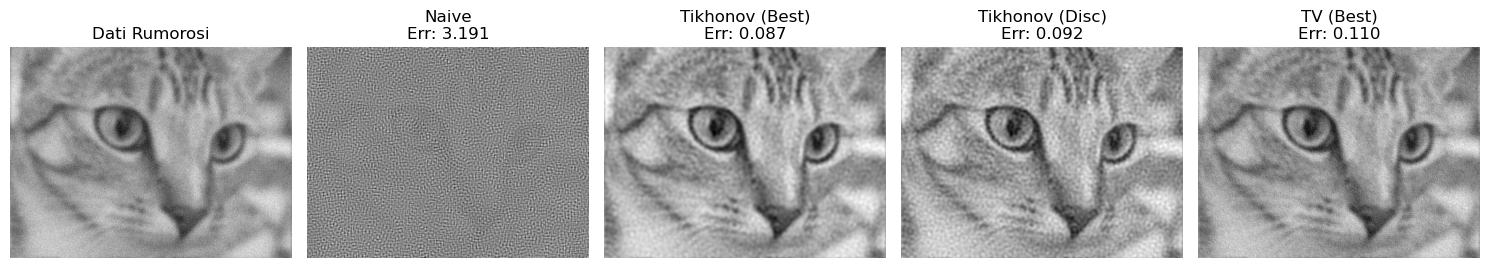

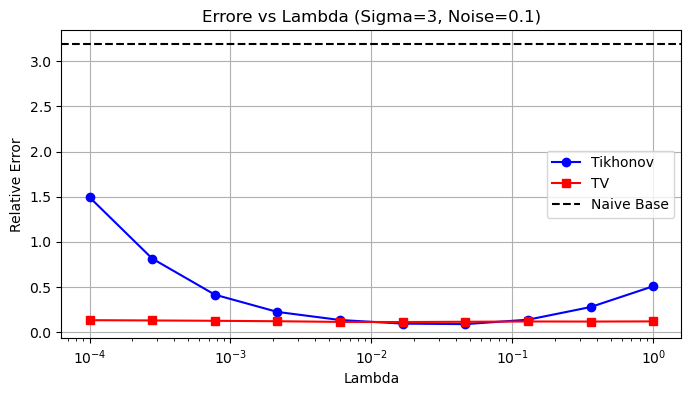


ANALISI CON PSF SIGMA = 5


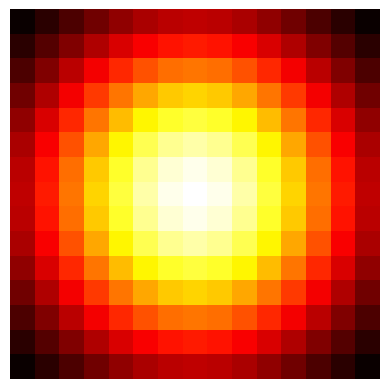


--- Livello di Rumore: 1.0% (Delta: 2.6824) ---
Calcolo soluzione Naive (CGLS)...
-> Naive Error: 0.2780
Calcolo soluzione Tikhonov...
-> Tikhonov Best (vs GT): Lambda=0.00599, Err=0.0649
-> Tikhonov Discrepancy: Lambda=0.00215, Err=0.0662
Calcolo soluzione Total Variation (Gradient Descent)...
-> TV Best (vs GT): Lambda=0.00010, Err=0.0706


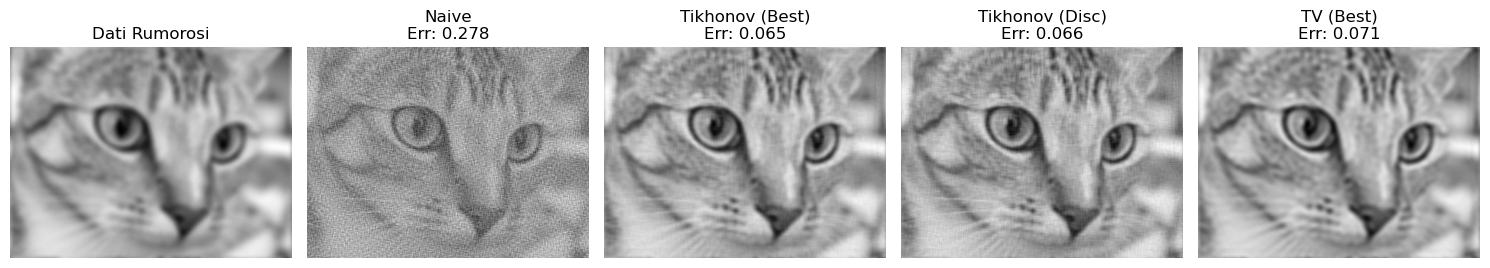

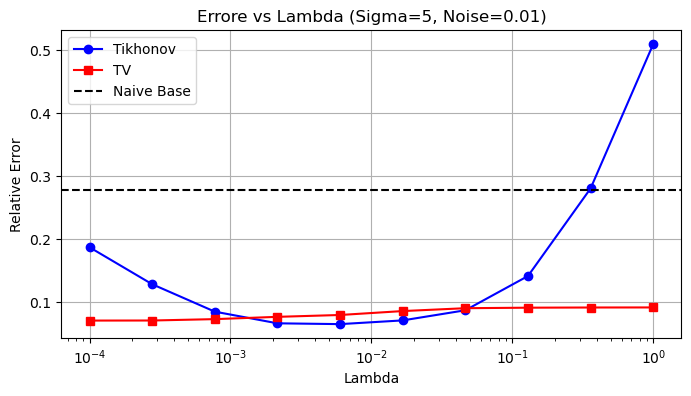


--- Livello di Rumore: 5.0% (Delta: 13.4121) ---
Calcolo soluzione Naive (CGLS)...
-> Naive Error: 1.4941
Calcolo soluzione Tikhonov...
-> Tikhonov Best (vs GT): Lambda=0.01668, Err=0.0801
-> Tikhonov Discrepancy: Lambda=0.00599, Err=0.1043
Calcolo soluzione Total Variation (Gradient Descent)...
-> TV Best (vs GT): Lambda=0.00077, Err=0.0863


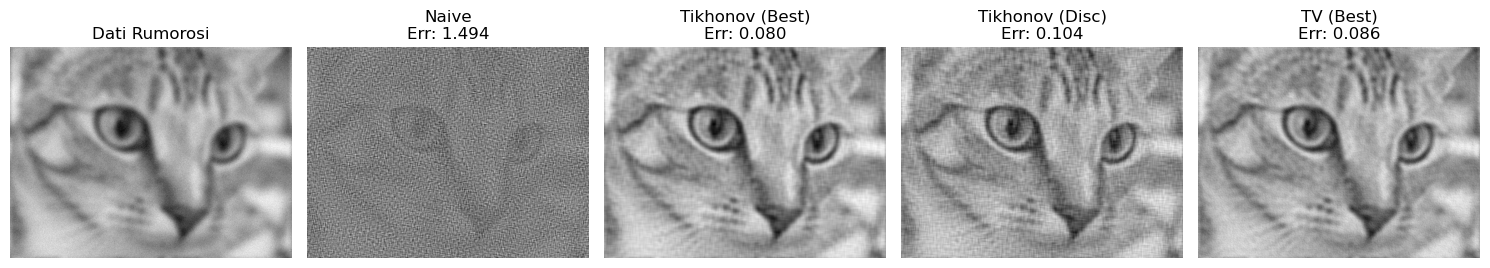

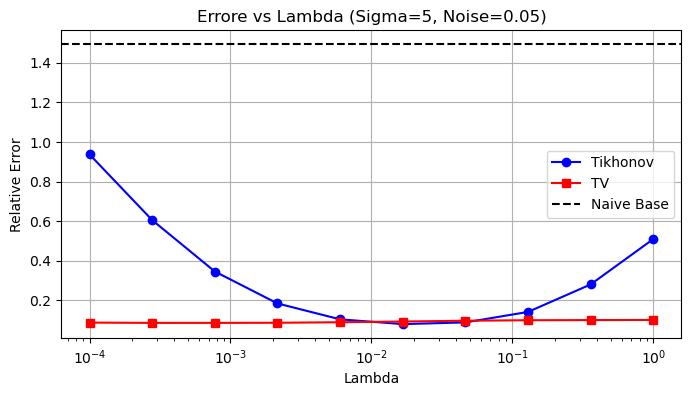


--- Livello di Rumore: 10.0% (Delta: 26.8242) ---
Calcolo soluzione Naive (CGLS)...
-> Naive Error: 3.0484
Calcolo soluzione Tikhonov...
-> Tikhonov Best (vs GT): Lambda=0.04642, Err=0.0940
-> Tikhonov Discrepancy: Lambda=0.01668, Err=0.1032
Calcolo soluzione Total Variation (Gradient Descent)...
-> TV Best (vs GT): Lambda=0.00599, Err=0.1172


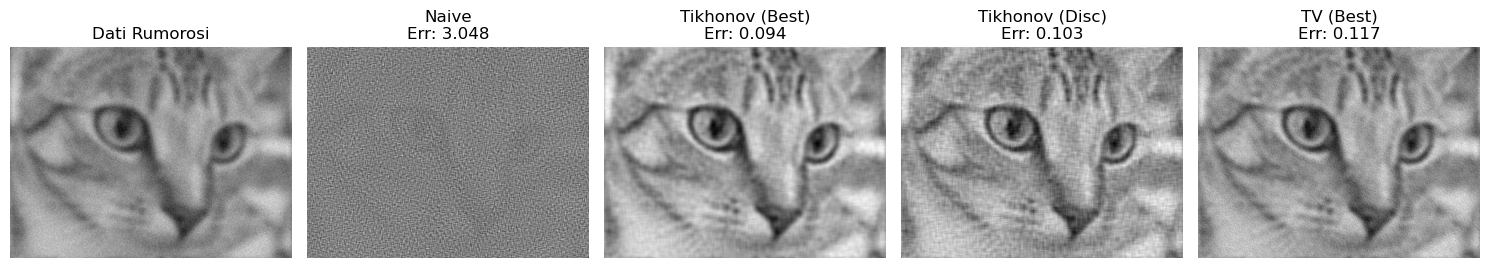

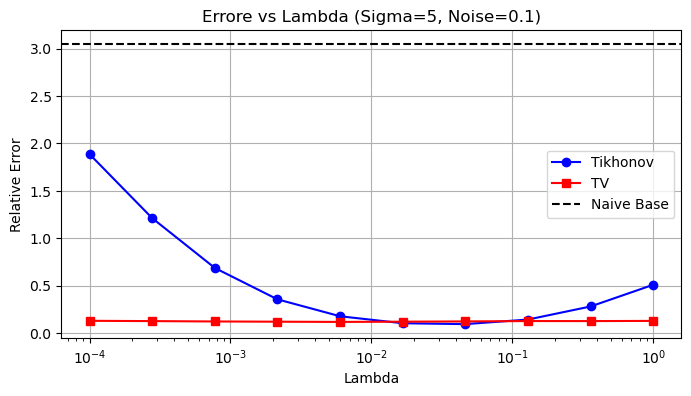

In [18]:
max_iter_cgls = 100
lambdas_tik = np.logspace(-4, 0, 10)
lambdas_tv = np.logspace(-4, 0, 10)
sigmas = [1, 3, 5]
noise_levels = [0.01, 0.05, 0.1]

test(A_img, max_iter_cgls, lambdas_tik, lambdas_tv, sigmas, noise_levels)